# FetchReach SAC with Factorised Critic

In [ ]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import copy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fetch_push_env import make_env
from utils import set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, TrajectoryReplayBuffer
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time
from networks import SAC_Critic
from agents import SAC_Actor
# from trainer import sac_train


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


In [ ]:
FETCH_REACH_LABELS = [
    "ee_x",
    "ee_y",
    "ee_z",
    "right_gripper_finger_joint_pos",
    "left_gripper_finger_joint_pos",
    "ee_vx",
    "ee_vy",
    "ee_vz",
    "right_gripper_finger_vel",
    "left_gripper_finger_vel",
]

def print_fetch_obs(obs):
    if isinstance(obs, dict):
        vec = obs["observation"]
        achieved = obs.get("achieved_goal", None)
        desired = obs.get("desired_goal", None)
    else:
        vec = obs
        achieved = None
        desired = None

    vec = np.asarray(vec).reshape(-1)

    print("Observation length:", len(vec))
    for i, (label, value) in enumerate(zip(FETCH_REACH_LABELS, vec)):
        print(f"{i:02d} {label:25s} {value: .6f}")

    if achieved is not None:
        print("\nachieved_goal:", np.asarray(achieved))
    if desired is not None:
        print("desired_goal  :", np.asarray(desired))

In [ ]:
goal = np.array([1.20, 0.75, 0.42], dtype=np.float32)

env_fn = make_env(
    goal=goal,
    reward_type="dense",
    max_episode_steps=100,
    render_mode="rgb_array",
    flatten_obs=True,
    goal_radius=0.05,
    use_native_reward=True,
)

env = env_fn()
obs, info = env.reset()
print_fetch_obs(obs)

frames = []

obs, info = env.reset()
done = False
while not done:
    frame = env.render()
    if frame is not None:
        frames.append(frame)

    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

plt.figure(figsize=(6, 6))
plt.imshow(frames[-1])
plt.axis("off")
plt.show()

env = env_fn()

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

print("Obs dim:", env.observation_space.shape)
print("Action dim:", env.action_space.shape)



In [1]:
import os
import numpy as np
import imageio.v2 as imageio
import gymnasium as gym
import gymnasium_robotics

from stable_baselines3 import SAC
from stable_baselines3.her.her_replay_buffer import HerReplayBuffer
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback


# ============================================================
# Configuration
# ============================================================

ENV_ID = "FetchReach-v4"

SEED = 42
MAX_EPISODE_STEPS = 50
TOTAL_TIMESTEPS = 100_000

# Select the target position here.
SELECTED_GOAL = np.array(
    [1.20, 0.75, 0.42],
    dtype=np.float32,
)

PROJECT_DIR = "sac_her_fetchreach"
BEST_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "best_model",
)
LOG_DIR = os.path.join(
    PROJECT_DIR,
    "logs",
)
VIDEO_DIR = os.path.join(
    PROJECT_DIR,
    "videos",
)

os.makedirs(BEST_MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)


# ============================================================
# Register Gymnasium-Robotics environments
# ============================================================

gym.register_envs(gymnasium_robotics)


# ============================================================
# Fixed-goal wrapper
# ============================================================

class FixedGoalWrapper(gym.Wrapper):
    """
    Forces FetchReach to use one selected target position.

    The observation remains a goal-conditioned dictionary:
        observation
        achieved_goal
        desired_goal
    """

    def __init__(self, env, goal):
        super().__init__(env)

        self.fixed_goal = np.asarray(
            goal,
            dtype=np.float32,
        ).reshape(-1)

        if self.fixed_goal.shape != (3,):
            raise ValueError(
                "Goal must have shape (3,), "
                f"got {self.fixed_goal.shape}"
            )

    def _set_goal(self, obs):
        # FetchReach stores the active target internally.
        self.env.unwrapped.goal = (
            self.fixed_goal.copy()
        )

        obs = dict(obs)
        obs["desired_goal"] = (
            self.fixed_goal.copy()
        )

        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        obs = self._set_goal(obs)

        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = (
            self.env.step(action)
        )

        obs = self._set_goal(obs)

        achieved_goal = np.asarray(
            obs["achieved_goal"],
            dtype=np.float32,
        )

        distance = float(
            np.linalg.norm(
                achieved_goal - self.fixed_goal
            )
        )

        info = dict(info)
        info["goal_dist"] = distance
        info["is_success"] = float(
            distance <= 0.05
        )

        return (
            obs,
            reward,
            terminated,
            truncated,
            info,
        )


# ============================================================
# Environment factory
# ============================================================

def make_fixed_goal_env(
    render_mode=None,
):
    base_env = gym.make(
        ENV_ID,
        reward_type="sparse",
        max_episode_steps=MAX_EPISODE_STEPS,
        render_mode=render_mode,
    )

    fixed_goal_env = FixedGoalWrapper(
        base_env,
        goal=SELECTED_GOAL,
    )

    return Monitor(fixed_goal_env)


# ============================================================
# Create training and evaluation environments
# ============================================================

train_env = make_fixed_goal_env(
    render_mode=None,
)

eval_env = make_fixed_goal_env(
    render_mode=None,
)


# ============================================================
# Environment smoke test
# ============================================================

obs, info = train_env.reset(seed=SEED)

print("Observation keys:", obs.keys())
print(
    "Observation shape:",
    obs["observation"].shape,
)
print(
    "Achieved goal:",
    obs["achieved_goal"],
)
print(
    "Desired goal:",
    obs["desired_goal"],
)
print(
    "Action space:",
    train_env.action_space,
)
print(
    "Selected goal:",
    SELECTED_GOAL,
)

assert set(obs.keys()) == {
    "observation",
    "achieved_goal",
    "desired_goal",
}

assert obs["observation"].shape == (10,)
assert obs["achieved_goal"].shape == (3,)
assert obs["desired_goal"].shape == (3,)
assert train_env.action_space.shape == (4,)

assert np.allclose(
    obs["desired_goal"],
    SELECTED_GOAL,
    atol=1e-6,
)

print("Environment smoke test passed.")


# ============================================================
# Evaluation callback
# ============================================================

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=BEST_MODEL_DIR,
    log_path=LOG_DIR,
    eval_freq=5_000,
    n_eval_episodes=20,
    deterministic=True,
    render=False,
)


# ============================================================
# SAC + HER model
# ============================================================

model = SAC(
    policy="MultiInputPolicy",
    env=train_env,

    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs={
        "n_sampled_goal": 4,
        "goal_selection_strategy": "future",
    },

    buffer_size=1_000_000,
    learning_starts=1_000,
    batch_size=256,

    learning_rate=3e-4,
    gamma=0.95,
    tau=0.005,

    ent_coef="auto",

    policy_kwargs={
        "net_arch": [256, 256, 256],
    },

    tensorboard_log=LOG_DIR,
    seed=SEED,
    verbose=1,
)


# ============================================================
# Train
# ============================================================

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True,
)


# ============================================================
# Save final model
# ============================================================

final_model_path = os.path.join(
    PROJECT_DIR,
    "sac_her_fetchreach_final",
)

model.save(final_model_path)

print(
    "Final model saved to:",
    final_model_path,
)


# ============================================================
# Load best model
# ============================================================

best_model_path = os.path.join(
    BEST_MODEL_DIR,
    "best_model",
)

best_model = SAC.load(
    best_model_path,
    env=eval_env,
)

print(
    "Best model loaded from:",
    best_model_path,
)


# ============================================================
# Deterministic evaluation
# ============================================================

def evaluate_model(
    model,
    env,
    num_episodes=100,
):
    successes = []
    returns = []
    lengths = []
    minimum_distances = []

    for episode in range(num_episodes):
        obs, info = env.reset(
            seed=1_000 + episode,
        )

        terminated = False
        truncated = False

        episode_return = 0.0
        episode_length = 0
        minimum_distance = float("inf")
        episode_success = False

        while not (terminated or truncated):
            action, _ = model.predict(
                obs,
                deterministic=True,
            )

            obs, reward, terminated, truncated, info = (
                env.step(action)
            )

            episode_return += float(reward)
            episode_length += 1

            if "goal_dist" in info:
                distance = float(
                    info["goal_dist"]
                )
            else:
                distance = float(
                    np.linalg.norm(
                        np.asarray(
                            obs["achieved_goal"],
                            dtype=np.float32,
                        )
                        - SELECTED_GOAL
                    )
                )

            minimum_distance = min(
                minimum_distance,
                distance,
            )

            if "is_success" in info:
                episode_success = bool(
                    info["is_success"]
                )
            elif distance <= 0.05:
                episode_success = True

        successes.append(
            float(episode_success)
        )
        returns.append(episode_return)
        lengths.append(episode_length)
        minimum_distances.append(
            minimum_distance
        )

    metrics = {
        "goal": SELECTED_GOAL.copy(),
        "success_rate": float(
            np.mean(successes)
        ),
        "mean_return": float(
            np.mean(returns)
        ),
        "return_std": float(
            np.std(returns)
        ),
        "mean_episode_length": float(
            np.mean(lengths)
        ),
        "mean_minimum_distance": float(
            np.mean(minimum_distances)
        ),
        "best_minimum_distance": float(
            np.min(minimum_distances)
        ),
    }

    return metrics


metrics = evaluate_model(
    best_model,
    eval_env,
    num_episodes=100,
)

print("\nEvaluation results:")

for key, value in metrics.items():
    print(f"{key}: {value}")


# ============================================================
# Generate GIF for the selected goal
# ============================================================

video_env = make_fixed_goal_env(
    render_mode="rgb_array",
)

obs, info = video_env.reset(seed=123)

frames = []
episode_return = 0.0
episode_length = 0
minimum_distance = float("inf")
success = False

frame = video_env.render()

if frame is not None:
    frames.append(np.asarray(frame))

terminated = False
truncated = False

while not (terminated or truncated):
    action, _ = best_model.predict(
        obs,
        deterministic=True,
    )

    obs, reward, terminated, truncated, info = (
        video_env.step(action)
    )

    episode_return += float(reward)
    episode_length += 1

    if "goal_dist" in info:
        distance = float(
            info["goal_dist"]
        )
    else:
        distance = float(
            np.linalg.norm(
                np.asarray(
                    obs["achieved_goal"],
                    dtype=np.float32,
                )
                - SELECTED_GOAL
            )
        )

    minimum_distance = min(
        minimum_distance,
        distance,
    )

    if "is_success" in info:
        success = bool(info["is_success"])
    elif distance <= 0.05:
        success = True

    frame = video_env.render()

    if frame is not None:
        frames.append(np.asarray(frame))

video_env.close()


# ============================================================
# Save GIF
# ============================================================

if len(frames) == 0:
    raise RuntimeError(
        "No frames were returned. "
        "Check render_mode='rgb_array'."
    )

video_path = os.path.join(
    VIDEO_DIR,
    "sac_her_fetchreach_fixed_goal.gif",
)

imageio.mimsave(
    video_path,
    frames,
    duration=1.0 / 20.0,
    loop=0,
)

print("\nGIF saved to:", video_path)
print("Goal:", SELECTED_GOAL)
print("Episode return:", episode_return)
print("Episode length:", episode_length)
print("Minimum distance:", minimum_distance)
print("Success:", success)
print("Number of frames:", len(frames))

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
Observation shape: (10,)
Achieved goal: [1.3418334  0.74910102 0.53473344]
Desired goal: [1.2  0.75 0.42]
Action space: Box(-1.0, 1.0, (4,), float32)
Selected goal: [1.2  0.75 0.42]
Environment smoke test passed.
Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to sac_her_fetchreach/logs/SAC_2


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-
packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-
packages/gymnasium/utils/passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was
expecting numpy array dtype to be float64, actual type: float32
  logger.warn(

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.2    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 1920     |
|    time_elapsed    | 0        |
|    total_timesteps | 200      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.5    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 8        |
|    fps             | 2047     |
|    time_elapsed    | 0        |
|    total_timesteps | 400      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -49.7    |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 12       |
|    fps      

...

Eval num_timesteps=100000, episode_reward=-2.00 +/- 0.00

Episode length: 50.00 +/- 0.00

Success rate: 100.00%

---------------------------------
| eval/              |          |
|    mean_ep_length  | 50       |
|    mean_reward     | -2       |
|    success_rate    | 1        |
| time/              |          |
|    total_timesteps | 100000   |
| train/             |          |
|    actor_loss      | 0.138    |
|    critic_loss     | 0.0127   |
|    ent_coef        | 0.000419 |
|    ent_coef_loss   | 13.1     |
|    learning_rate   | 0.0003   |
|    n_updates       | 98999    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -2.18    |
|    success_rate    | 1        |
| time/              |          |
|    episodes        | 2000     |
|    fps             | 132      |
|    time_elapsed    | 753      |
|    total_timesteps | 100000   |
---------------------------------


Final model saved to: sac_her_fetchreach/sac_her_fetchreach_final
Wrapping the env in a DummyVecEnv.
Best model loaded from: sac_her_fetchreach/best_model/best_model

Evaluation results:
goal: [1.2  0.75 0.42]
success_rate: 1.0
mean_return: -2.0
return_std: 0.0
mean_episode_length: 50.0
mean_minimum_distance: 0.0032570187468081713
best_minimum_distance: 0.0032570187468081713

GIF saved to: sac_her_fetchreach/videos/sac_her_fetchreach_fixed_goal.gif
Goal: [1.2  0.75 0.42]
Episode return: -2.0
Episode length: 50
Minimum distance: 0.0032570187468081713
Success: True
Number of frames: 51


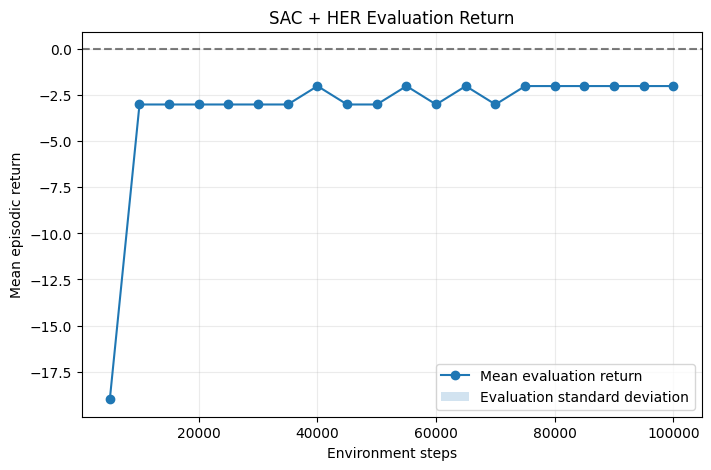

In [2]:
import numpy as np
import matplotlib.pyplot as plt


eval_steps = np.asarray(
    eval_callback.evaluations_timesteps
)

eval_results = np.asarray(
    eval_callback.evaluations_results
)

# Shape:
# eval_results = (number_of_evaluations, episodes_per_evaluation)

mean_eval_returns = eval_results.mean(
    axis=1
)

std_eval_returns = eval_results.std(
    axis=1
)

plt.figure(figsize=(8, 5))

plt.plot(
    eval_steps,
    mean_eval_returns,
    marker="o",
    label="Mean evaluation return",
)

plt.fill_between(
    eval_steps,
    mean_eval_returns - std_eval_returns,
    mean_eval_returns + std_eval_returns,
    alpha=0.2,
    label="Evaluation standard deviation",
)

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("Environment steps")
plt.ylabel("Mean episodic return")
plt.title("SAC + HER Evaluation Return")
plt.grid(alpha=0.25)
plt.legend()
plt.show()